# Data Prep: 6 - World GDP / Population / CO2 Emissions

Steps:
1. Initial Data Exploration
2. Handling Missing Values
3. Dealing with Duplicates
4. Handling Outliers
5. Data Manipulation (Lag Features)
6. Partitioning Dataset (Train / Validation / Test — same ratios as `1-vehicle_emission_data_prep.ipynb`)
7. Feature Scaling + Export (StandardScaler, leakage-free)
8. Visualizing Data


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RAW_PATH = Path("data/raw/6-World_GDP_Population_CO2_Emissions_Dataset.csv")
assert RAW_PATH.exists(), f"Missing dataset: {RAW_PATH}"

TARGET_COL = "Fossil CO2 Emissions (tons)"

# Step 1: Initial Data Exploration
df = pd.read_csv(RAW_PATH)
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
display(df.head())

print("Columns:")
print(list(df.columns))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nBasic stats (numeric):")
display(df.describe(include=[np.number]))


Shape: (46, 11)


,Year,GDP Real (USD),GDP growth (%),Per Capita,World Population,Net Change,Population change (%),Fossil CO2 Emissions (tons),CO2 emissions change,CO2 emissions per capita,Population Density (P/Km²)
0,2022,9.080000e+13,0.0324,11317,8021407192,66958801,0.0084,38521997860,0.0115,4.80,54
1,2021,8.790000e+13,0.0635,11054,7954448391,67447099,0.0086,38082163770,0.0595,4.79,53
2,2020,8.270000e+13,-0.0288,10483,7887001292,75707594,0.0097,35944470190,-0.0497,4.56,53
3,2019,8.510000e+13,0.0268,10898,7811293698,81390917,0.0105,37824905990,-0.0002,4.84,52
4,2018,8.290000e+13,0.0328,10726,7729902781,84284827,0.0110,37831867370,0.0255,4.89,52


Columns:
['Year', 'GDP Real (USD)', 'GDP growth (%)', 'Per Capita', 'World Population', 'Net Change', 'Population change (%)', 'Fossil CO2 Emissions (tons)', 'CO2 emissions change', 'CO2 emissions per capita', 'Population Density (P/Km²)']

Missing values:


Year                           0
GDP Real (USD)                 0
GDP growth (%)                 0
Per Capita                     0
World Population               0
Net Change                     0
Population change (%)          0
Fossil CO2 Emissions (tons)    0
CO2 emissions change           0
CO2 emissions per capita       0
Population Density (P/Km²)     0
dtype: int64


Basic stats (numeric):


,Year,GDP Real (USD),GDP growth (%),Per Capita,World Population,Net Change,Population change (%),Fossil CO2 Emissions (tons),CO2 emissions change,CO2 emissions per capita,Population Density (P/Km²)
count,46.000000,4.600000e+01,46.000000,46.000000,4.600000e+01,4.600000e+01,46.000000,4.600000e+01,46.000000,46.000000,46.000000
mean,1999.500000,5.097609e+13,0.030350,8006.326087,6.128450e+09,8.428610e+07,0.014463,2.745007e+10,0.016337,4.440435,41.152174
std,13.422618,2.013534e+13,0.015413,1720.809526,1.150810e+09,5.921616e+06,0.002909,6.724902e+09,0.020672,0.312644,7.720010
min,1977.000000,2.400000e+13,-0.028800,5685.000000,4.217864e+09,6.695880e+07,0.008400,1.900807e+10,-0.049700,4.030000,28.000000
25%,1988.250000,3.412500e+13,0.026425,6612.000000,5.165102e+09,8.264763e+07,0.012725,2.204355e+10,0.006125,4.150000,35.000000
50%,1999.500000,4.735000e+13,0.032350,7729.000000,6.130355e+09,8.438336e+07,0.013600,2.522144e+10,0.016550,4.365000,41.000000
75%,2010.750000,6.665000e+13,0.039950,9398.750000,7.088626e+09,8.873391e+07,0.017800,3.464557e+10,0.031150,4.780000,47.750000
max,2022.000000,9.080000e+13,0.063500,11317.000000,8.021407e+09,9.337138e+07,0.018500,3.852200e+10,0.061200,4.950000,54.000000


## Step 2: Handling Missing Values

For this dataset, we typically keep the rows and rely on the imputer later. Here we at least ensure `Year` exists.

In [2]:
df_work = df.copy()

# Year is required for time-based splitting
df_work["Year"] = pd.to_numeric(df_work["Year"], errors="coerce")
before = len(df_work)
df_work = df_work.dropna(subset=["Year"]).copy()
print(f"Rows dropped due to missing/invalid Year: {before - len(df_work):,}")

print("Remaining missing values:")
display(df_work.isna().sum().sort_values(ascending=False))


Rows dropped due to missing/invalid Year: 0
Remaining missing values:


Year                           0
GDP Real (USD)                 0
GDP growth (%)                 0
Per Capita                     0
World Population               0
Net Change                     0
Population change (%)          0
Fossil CO2 Emissions (tons)    0
CO2 emissions change           0
CO2 emissions per capita       0
Population Density (P/Km²)     0
dtype: int64

## Step 3: Dealing with Duplicates

We remove duplicates by `Year` (time series should be unique per year).

In [3]:
dup_rows = df_work.duplicated().sum()
print("Duplicate rows (full-row):", dup_rows)

df_work = df_work.drop_duplicates(subset=["Year"], keep="first").copy()
print("Shape after dropping Year duplicates:", df_work.shape)


Duplicate rows (full-row): 0
Shape after dropping Year duplicates: (46, 11)


## Step 4: Handling Outliers

We cap numeric outliers using IQR for all numeric columns except `Year`.

In [4]:
def cap_outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    if s.dropna().empty:
        return s
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return s
    low = q1 - k * iqr
    high = q3 + k * iqr
    return s.clip(low, high)

for c in df_work.columns:
    if c == "Year":
        continue
    df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

numeric_cols = [c for c in df_work.columns if c != "Year" and pd.api.types.is_numeric_dtype(df_work[c])]
for c in numeric_cols:
    df_work[c] = cap_outliers_iqr(df_work[c])

print("Outlier capping done for:", numeric_cols)


Outlier capping done for: ['GDP Real (USD)', 'GDP growth (%)', 'Per Capita', 'World Population', 'Net Change', 'Population change (%)', 'Fossil CO2 Emissions (tons)', 'CO2 emissions change', 'CO2 emissions per capita', 'Population Density (P/Km²)']


## Step 5: Data Manipulation (Lag Features)

Create lag-1 features for key variables so the model can use temporal patterns.
This is a simple time-series feature engineering approach.

In [5]:
assert TARGET_COL in df_work.columns, f"Missing target: {TARGET_COL}"

df_work = df_work.sort_values("Year").copy()

LAG_COLS = [
    TARGET_COL,
    "CO2 emissions per capita",
    "World Population",
    "GDP Real (USD)",
    "GDP growth (%)",
]
LAG_COLS = [c for c in LAG_COLS if c in df_work.columns]

for c in LAG_COLS:
    df_work[f"{c} (lag1)"] = df_work[c].shift(1)

lag_feature_cols = [f"{c} (lag1)" for c in LAG_COLS]
df_model = df_work.dropna(subset=lag_feature_cols).copy()
print("Shape after creating lag features:", df_model.shape)


Shape after creating lag features: (45, 16)


## Step 6: Partitioning Dataset (Train / Validation / Test)

Same approach as `1-vehicle_emission_data_prep.ipynb`: **random** split with `random_state=42` — hold out **20%** test, then split the remainder **75% train / 25% validation** → **~60% / 20% / 20%** overall.  
(Not time-ordered; use only if you accept i.i.d.-style sampling for this small panel.)

In [6]:
feature_cols = [c for c in df_model.columns if c not in ["Year", TARGET_COL]]
X = df_model[feature_cols]
y = df_model[TARGET_COL]

# Stage 1: hold out 20% as the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Stage 2: split remainder into 75% train / 25% validation → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set:    {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set:  {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:        {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget ({TARGET_COL}) stats (train):\n{y_train.describe()}")


Train size: 36 Test size: 9


## Step 7: Feature Scaling + Export

Standardize continuous numeric columns using **train-only** `fit`, then save the full modeling frame and **scaled** `X_train` / `X_val` / `X_test` CSVs (same pattern as `1-vehicle_emission_data_prep.ipynb`).  
`6-world_preprocessor.joblib` is now a small bundle: `standard_scaler`, `scale_cols`, and `target_col` (replacing the old `ColumnTransformer`).


In [7]:
# Scale only continuous numeric features (exclude binary columns if any)
scale_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Standardization applied to:", scale_cols)
print(f"\nTrain feature means (should be ~0):\n{X_train_scaled[scale_cols].mean().round(4)}")
print(f"\nTrain feature std (should be ~1):\n{X_train_scaled[scale_cols].std().round(4)}")

PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_out_path = PROCESSED_DIR / "6-world_gdp_population_co2_emissions_cleaned.csv"
df_model.to_csv(df_out_path, index=False)
print("\nSaved modeling dataframe to:", df_out_path)

# Scaled train / validation / test (leakage-free)
X_train_scaled.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_X_train.csv", index=False)
X_val_scaled.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_X_val.csv", index=False)
X_test_scaled.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_X_test.csv", index=False)
y_train.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_y_train.csv", index=False, header=True)
y_val.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_y_val.csv", index=False, header=True)
y_test.to_csv(PROCESSED_DIR / "6-world_gdp_population_co2_emissions_y_test.csv", index=False, header=True)

print("Saved splits:")
print(f"  X_train: {X_train_scaled.shape}  →  6-world_gdp_population_co2_emissions_X_train.csv")
print(f"  X_val:   {X_val_scaled.shape}   →  6-world_gdp_population_co2_emissions_X_val.csv")
print(f"  X_test:  {X_test_scaled.shape}   →  6-world_gdp_population_co2_emissions_X_test.csv")

prep_bundle = {
    "standard_scaler": scaler,
    "scale_cols": scale_cols,
    "target_col": TARGET_COL,
}
prep_out_path = PROCESSED_DIR / "6-world_preprocessor.joblib"
joblib.dump(prep_bundle, prep_out_path)
print("Saved scaler bundle to:", prep_out_path)


X_train_prep shape: (36, 14)
X_test_prep shape: (9, 14)
Saved modeling dataframe to: data/processed/6-world_gdp_population_co2_emissions_cleaned.csv
Saved preprocessor to: data/processed/6-world_preprocessor.joblib


## Step 8: Visualizing Data


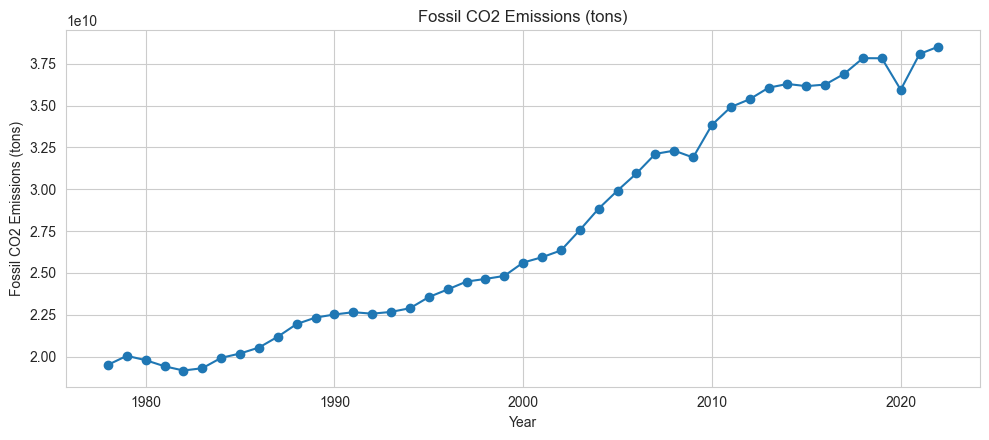

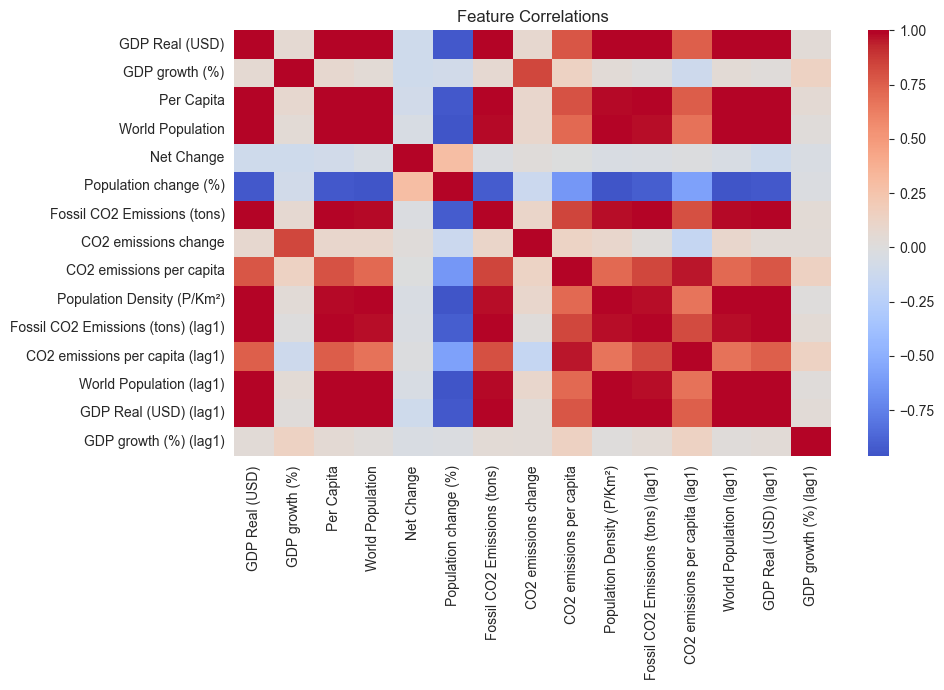

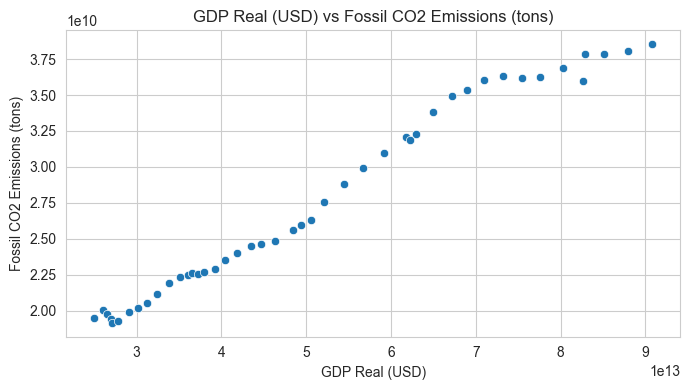

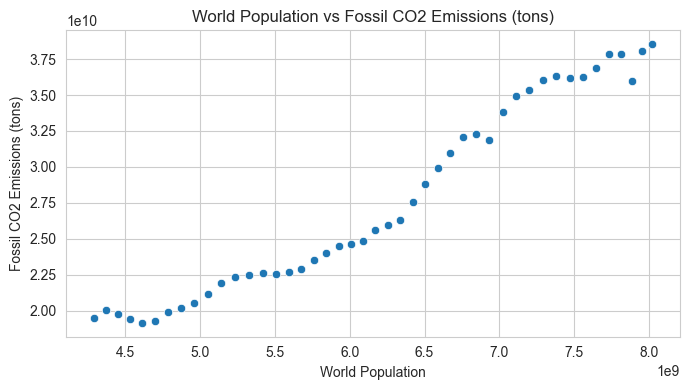

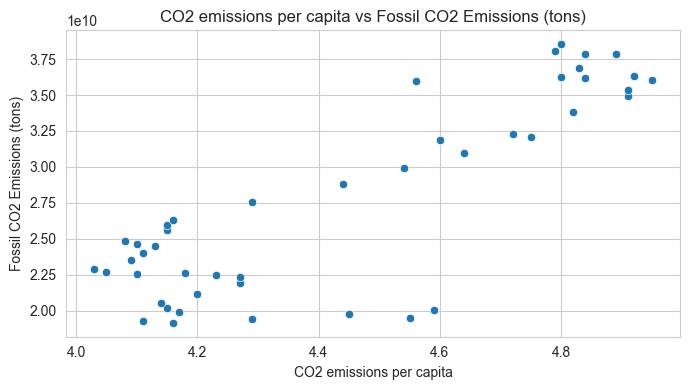

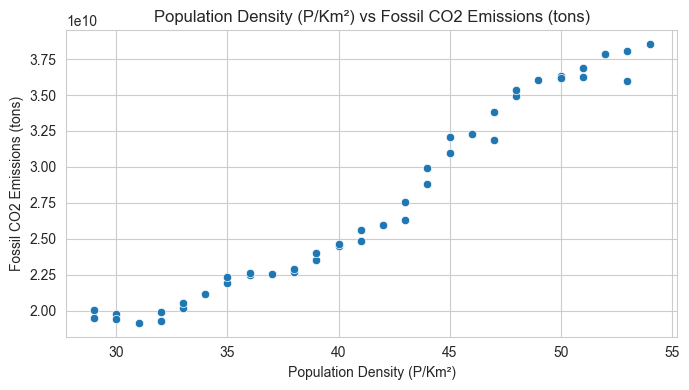

In [8]:
plot_df = df_model.copy()

# Target over time
plt.figure(figsize=(10, 4.5))
plt.plot(plot_df["Year"], plot_df[TARGET_COL], marker="o")
plt.title(TARGET_COL)
plt.xlabel("Year")
plt.ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = plot_df.drop(columns=["Year"], errors="ignore").select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 7))
sns.heatmap(plot_df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

# Scatter plots vs target
scatter_cols = ["GDP Real (USD)", "World Population", "CO2 emissions per capita", "Population Density (P/Km²)"]
for c in scatter_cols:
    if c in plot_df.columns:
        plt.figure(figsize=(7, 4))
        sns.scatterplot(data=plot_df, x=c, y=TARGET_COL)
        plt.title(f"{c} vs {TARGET_COL}")
        plt.tight_layout()
        plt.show()
